# Inspect paired traces
Loads a wk28 pair H5 file, prints shapes for the 30th event (idx=29), and plots noisy/clean traces to verify alignment.

Generated 10 events
Sample shapes (noisy, clean): (56, 65536) (56, 65536)
Sample position (first event): (array([-5.01100696]), array([-85.90804444]), array([-1696.62183627]))
Channel with max energy: 26, correlation argmax shift: 65524


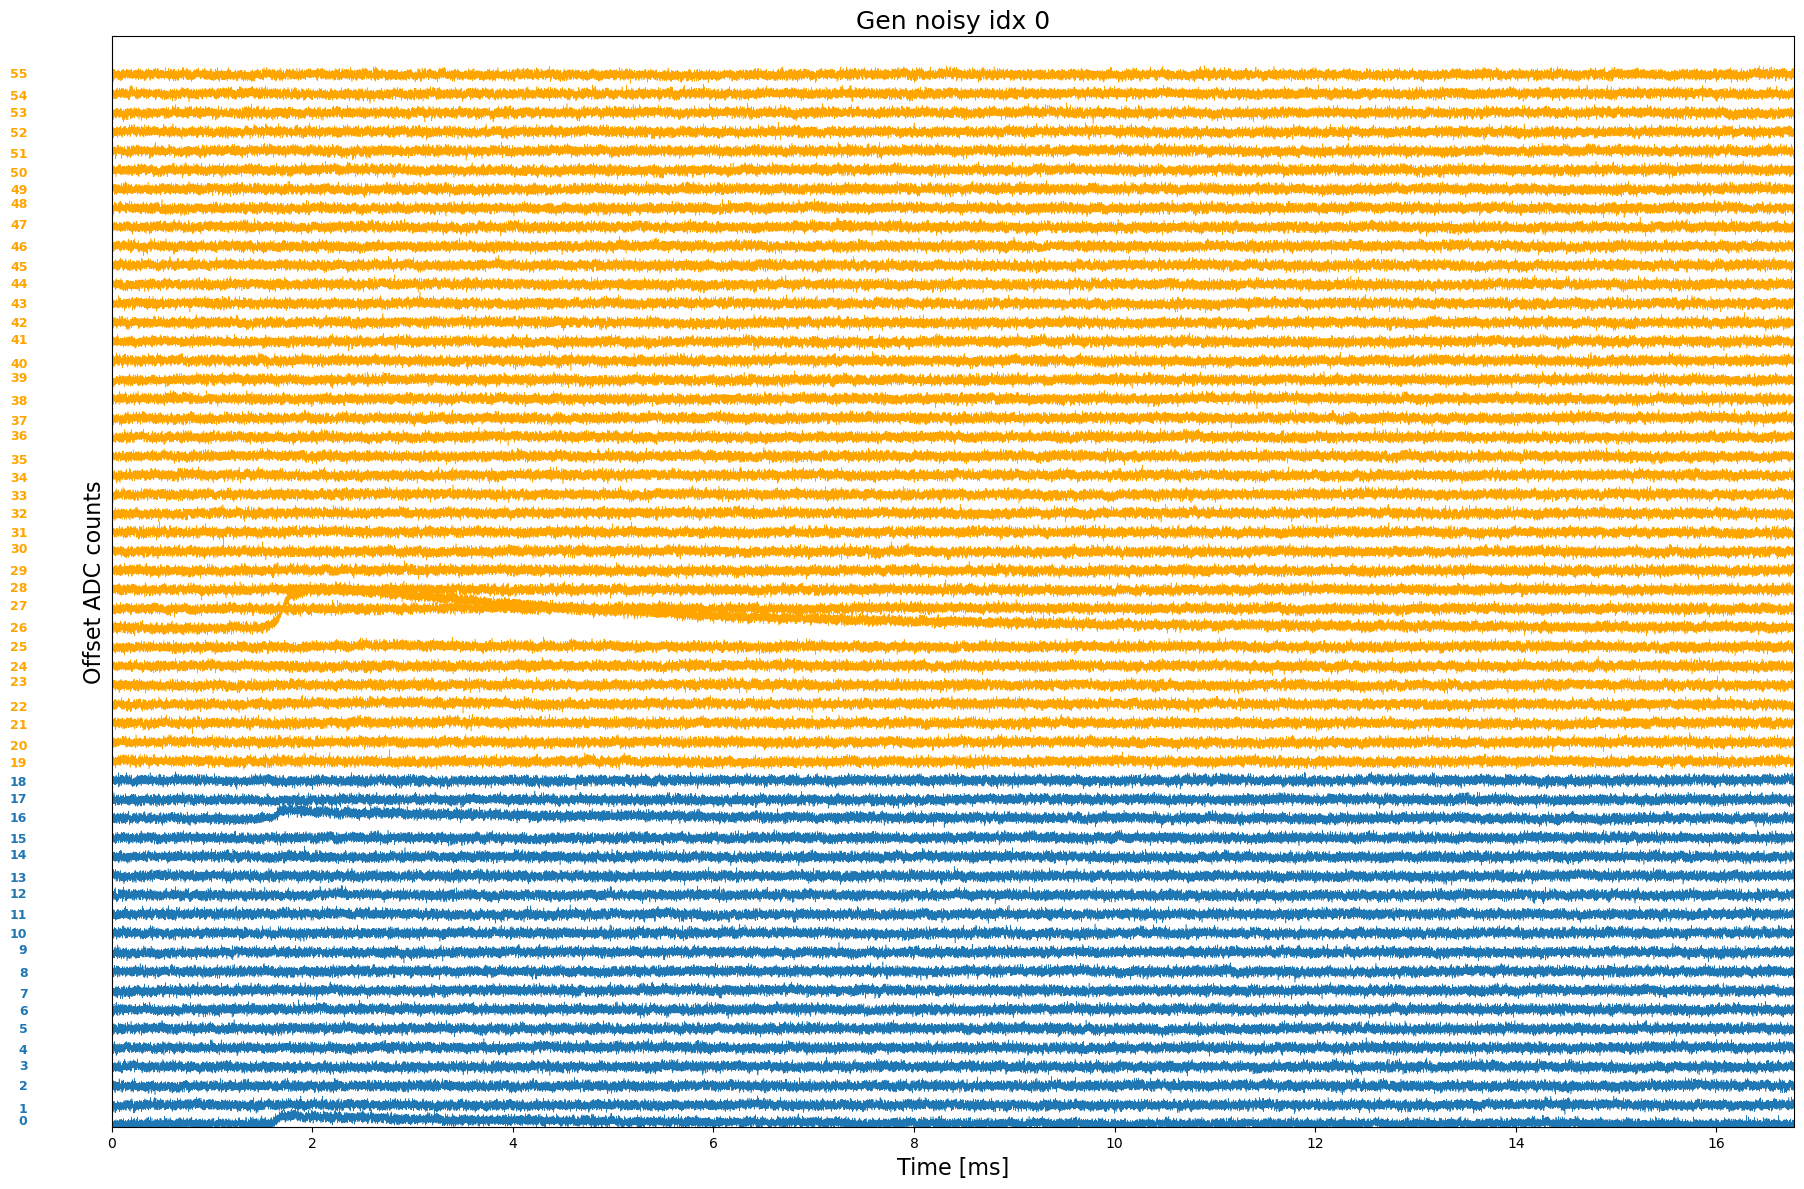

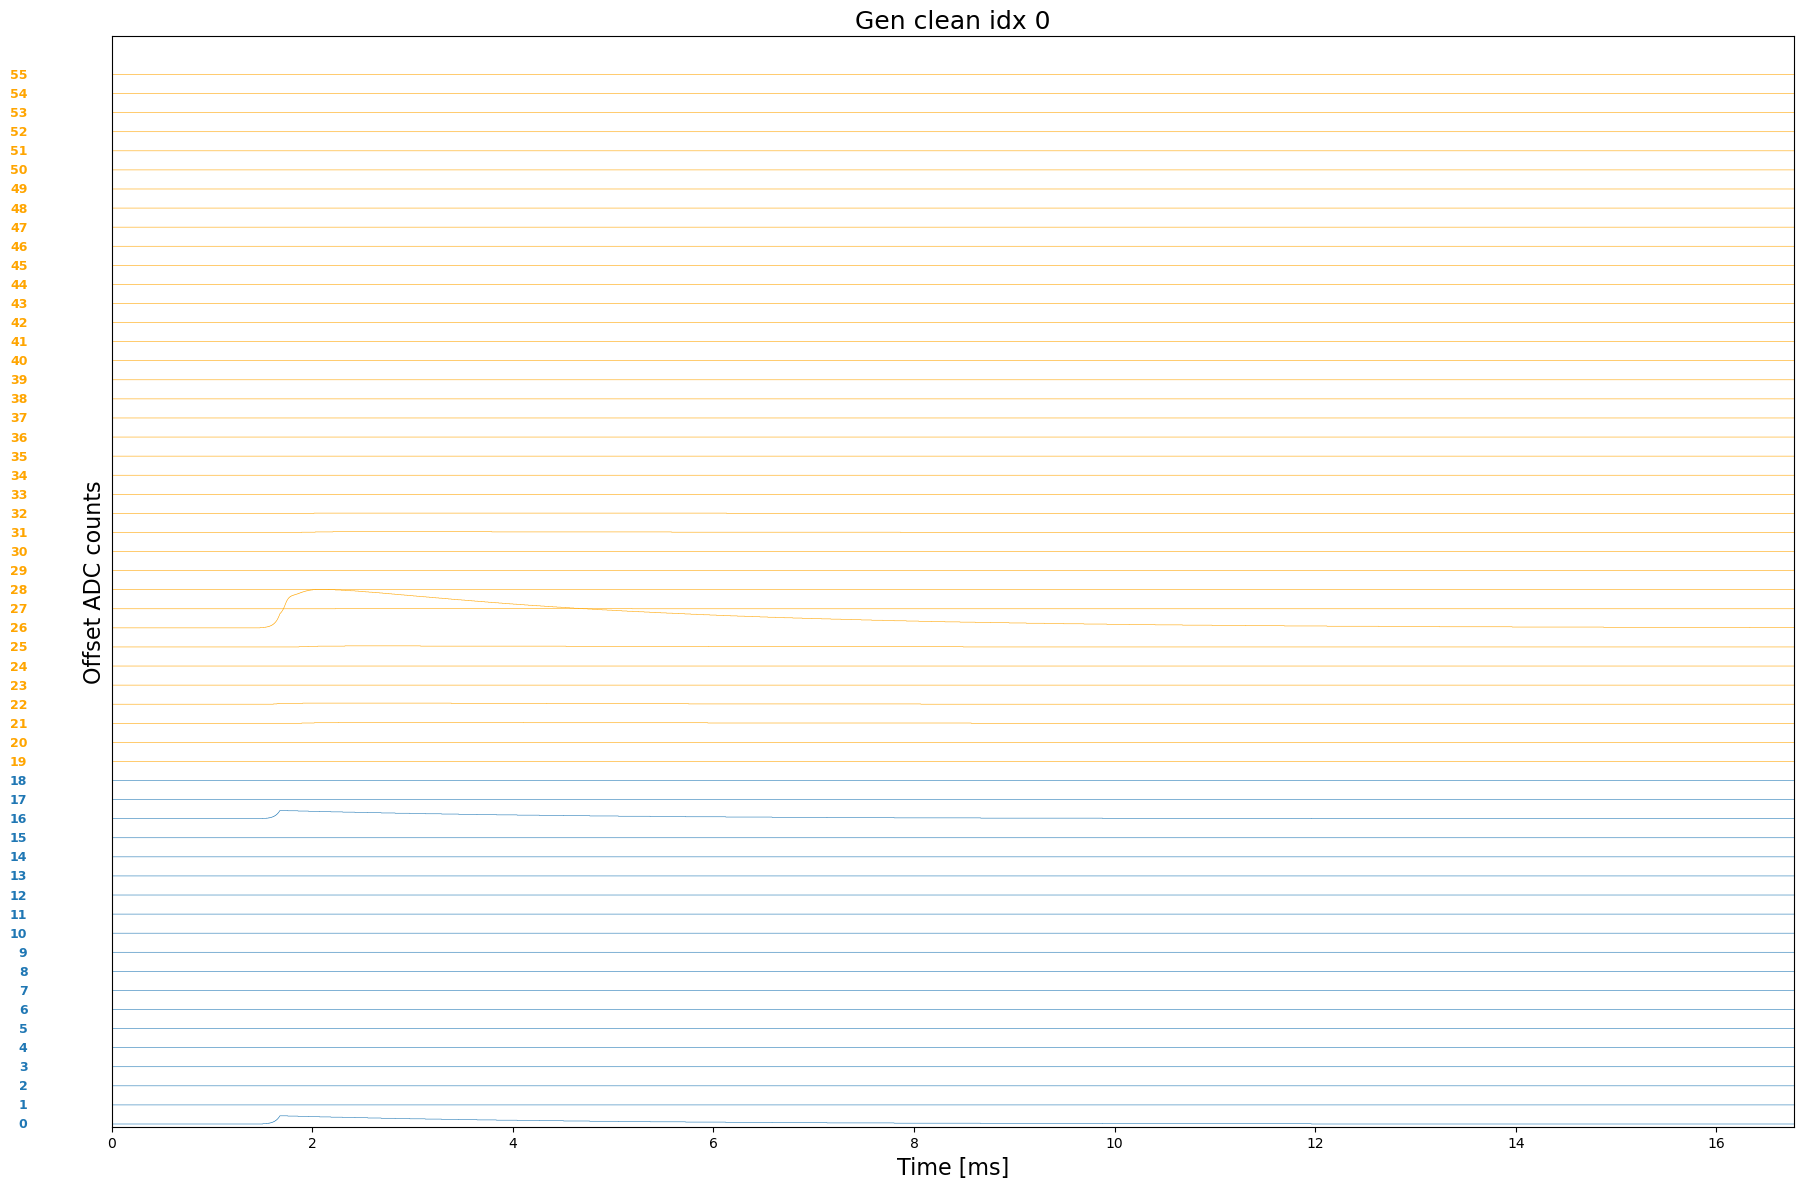

In [7]:
"""Quick smoke test: generate 10 paired events in-memory with the same config as make_traces_pair.py."""
import yaml
import numpy as np
from TraceSimulator import LongTraceSimulator
from trace_IO import plot_traces

CONFIG_PATH = "/home/dwong/DELight_mtr/trigger_study/archive/wk24/training_config_small.yaml"
ENERGY = 200.0
RECOIL_TYPE = "NR"
PHONON_ONLY = False
NO_NOISE = False
QUANTIZE = True
ROUTE_ALL_SIGNAL_TO_CH0 = False

with open(CONFIG_PATH, "r") as f:
    CONFIG = yaml.safe_load(f)

def generate_pair(lts: LongTraceSimulator):
    out = lts.generate(
        E=ENERGY,
        type_recoil=RECOIL_TYPE,
        phonon_only=PHONON_ONLY,
        no_noise=NO_NOISE,
        quantize=QUANTIZE,
        return_signal_mask=False,
        route_all_signal_to_ch0=ROUTE_ALL_SIGNAL_TO_CH0,
        return_pair=True,
    )

    pos = None
    if isinstance(out, tuple) and len(out) == 2 and isinstance(out[0], tuple):
        clean_ts, noisy_ts = out[0]
        if isinstance(out[1], tuple) and len(out[1]) == 3:
            pos = out[1]
    else:
        clean_ts, noisy_ts = out
    return noisy_ts[0].astype(np.float32), clean_ts[0].astype(np.float32), pos

lts = LongTraceSimulator(CONFIG)
pairs = [generate_pair(lts) for _ in range(10)]

print(f"Generated {len(pairs)} events")
print("Sample shapes (noisy, clean):", pairs[0][0].shape, pairs[0][1].shape)
print("Sample position (first event):", pairs[0][2])

sample_idx = 0
noisy_ev, clean_ev, _ = pairs[sample_idx]

# Quick alignment check: find channel with largest energy and report correlation shift
total_energy = (np.abs(clean_ev)).sum(axis=1)
ch = int(np.argmax(total_energy))
na = noisy_ev[ch] - noisy_ev[ch].mean()
ca = clean_ev[ch] - clean_ev[ch].mean()
shift = int(np.argmax(np.fft.irfft(np.fft.rfft(na) * np.conj(np.fft.rfft(ca)))))
print(f"Channel with max energy: {ch}, correlation argmax shift: {shift}")

plot_traces(noisy_ev, title=f"Gen noisy idx {sample_idx}")
plot_traces(clean_ev, title=f"Gen clean idx {sample_idx}")
